In [17]:


import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



In [18]:
path="cancer_classification.csv"
df = pd.read_csv(path)
print(df.shape)
print(df.columns)


(569, 31)
Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'benign_0__mal_1'],
      dtype='str')


The objective of this dataset is to classify cancer samples into two categories:
- **Benign (Non-Cancerous)**
- **Malignant (Cancerous)**
* The dataset has 569 rows and 31 columns.

In [19]:
print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [20]:
print(df.isnull().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
benign_0__mal_1            0
dtype: int64


* There are no null value present in the dataset.

In [21]:
df.duplicated().sum()

np.int64(0)

* There are no duplicates value in this dataset

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [23]:
df["benign_0__mal_1"].value_counts()

benign_0__mal_1
1    357
0    212
Name: count, dtype: int64

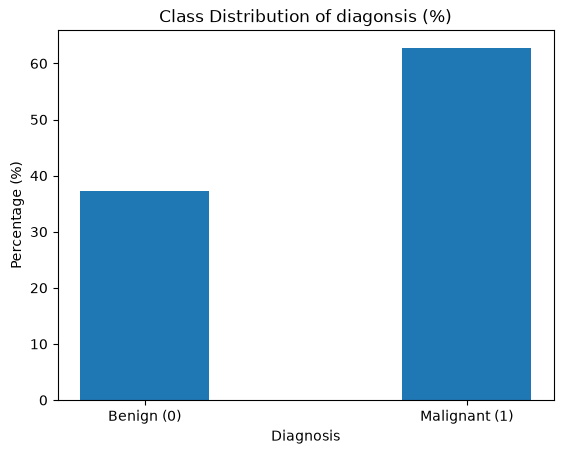

In [24]:
class_percentage = df["benign_0__mal_1"].value_counts(normalize=True) * 100

plt.bar(["Benign (0)", "Malignant (1)"], 
        [class_percentage[0], class_percentage[1]],width=0.4)

plt.title("Class Distribution of diagonsis (%)")
plt.xlabel("Diagnosis")
plt.ylabel("Percentage (%)")

plt.show()

In [25]:
class_percent = df["benign_0__mal_1"].value_counts(normalize=True) * 100

print(f"Benign: {class_percent[0]:.2f}%")
print(f"Malignant: {class_percent[1]:.2f}%")

Benign: 37.26%
Malignant: 62.74%


 *  From the dataset,it is concluded that
 *  There are 37.62 % non-cancerous cells
 *   There are 62.74 % cancerous cells

**DETERMINING TARGET AND FEATURE**

In [26]:
x=df.drop(["benign_0__mal_1"],axis=1)
y=df["benign_0__mal_1"]

**DETERMINING CORREALTION******

In [27]:
target_corr = (
    df.corr(numeric_only=True)["benign_0__mal_1"]
    .abs()
    .sort_values(ascending=False)
)

print(target_corr)

benign_0__mal_1            1.000000
worst concave points       0.793566
worst perimeter            0.782914
mean concave points        0.776614
worst radius               0.776454
mean perimeter             0.742636
worst area                 0.733825
mean radius                0.730029
mean area                  0.708984
mean concavity             0.696360
worst concavity            0.659610
mean compactness           0.596534
worst compactness          0.590998
radius error               0.567134
perimeter error            0.556141
area error                 0.548236
worst texture              0.456903
worst smoothness           0.421465
worst symmetry             0.416294
mean texture               0.415185
concave points error       0.408042
mean smoothness            0.358560
mean symmetry              0.330499
worst fractal dimension    0.323872
compactness error          0.292999
concavity error            0.253730
fractal dimension error    0.077972
smoothness error           0

**EDA**

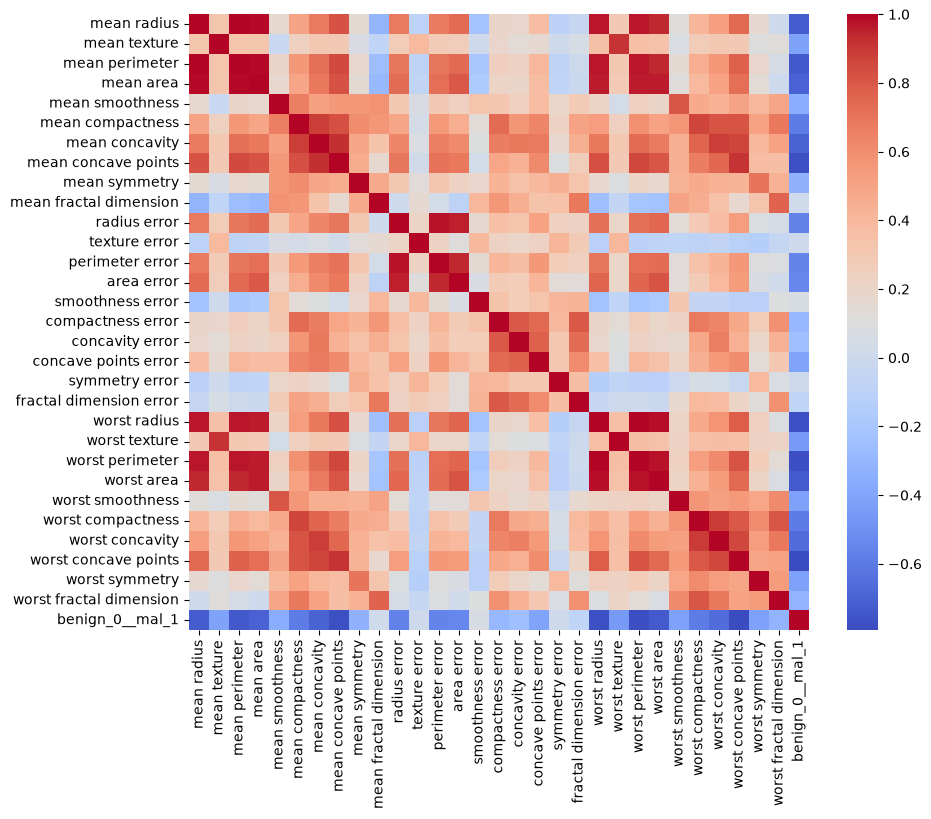

In [28]:
plt.figure(figsize=(10, 8))

sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')

plt.show()

From the heatmap:
* mean radius and worst radius are strongly correlated.
* mean texture and worst texture are strongly correlated.
* mean area and worst area are strongly correlated.

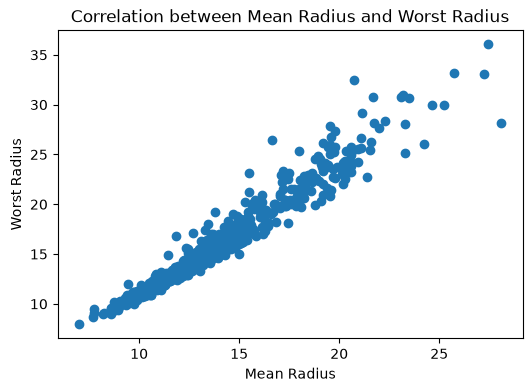

In [29]:
plt.figure(figsize=(6, 4))

plt.scatter(df['mean radius'], df['worst radius'])

plt.xlabel('Mean Radius')
plt.ylabel('Worst Radius')
plt.title('Correlation between Mean Radius and Worst Radius')

plt.show()

**CONCLUSION FROM CORRELATION GRAPH BETWEEN MEAN RADIUS AND WORST RADIUS**
* There is a strong positive relationship between Mean Radius and Worst Radius.
* As the Mean Radius increases, the Worst Radius also tends to increase.

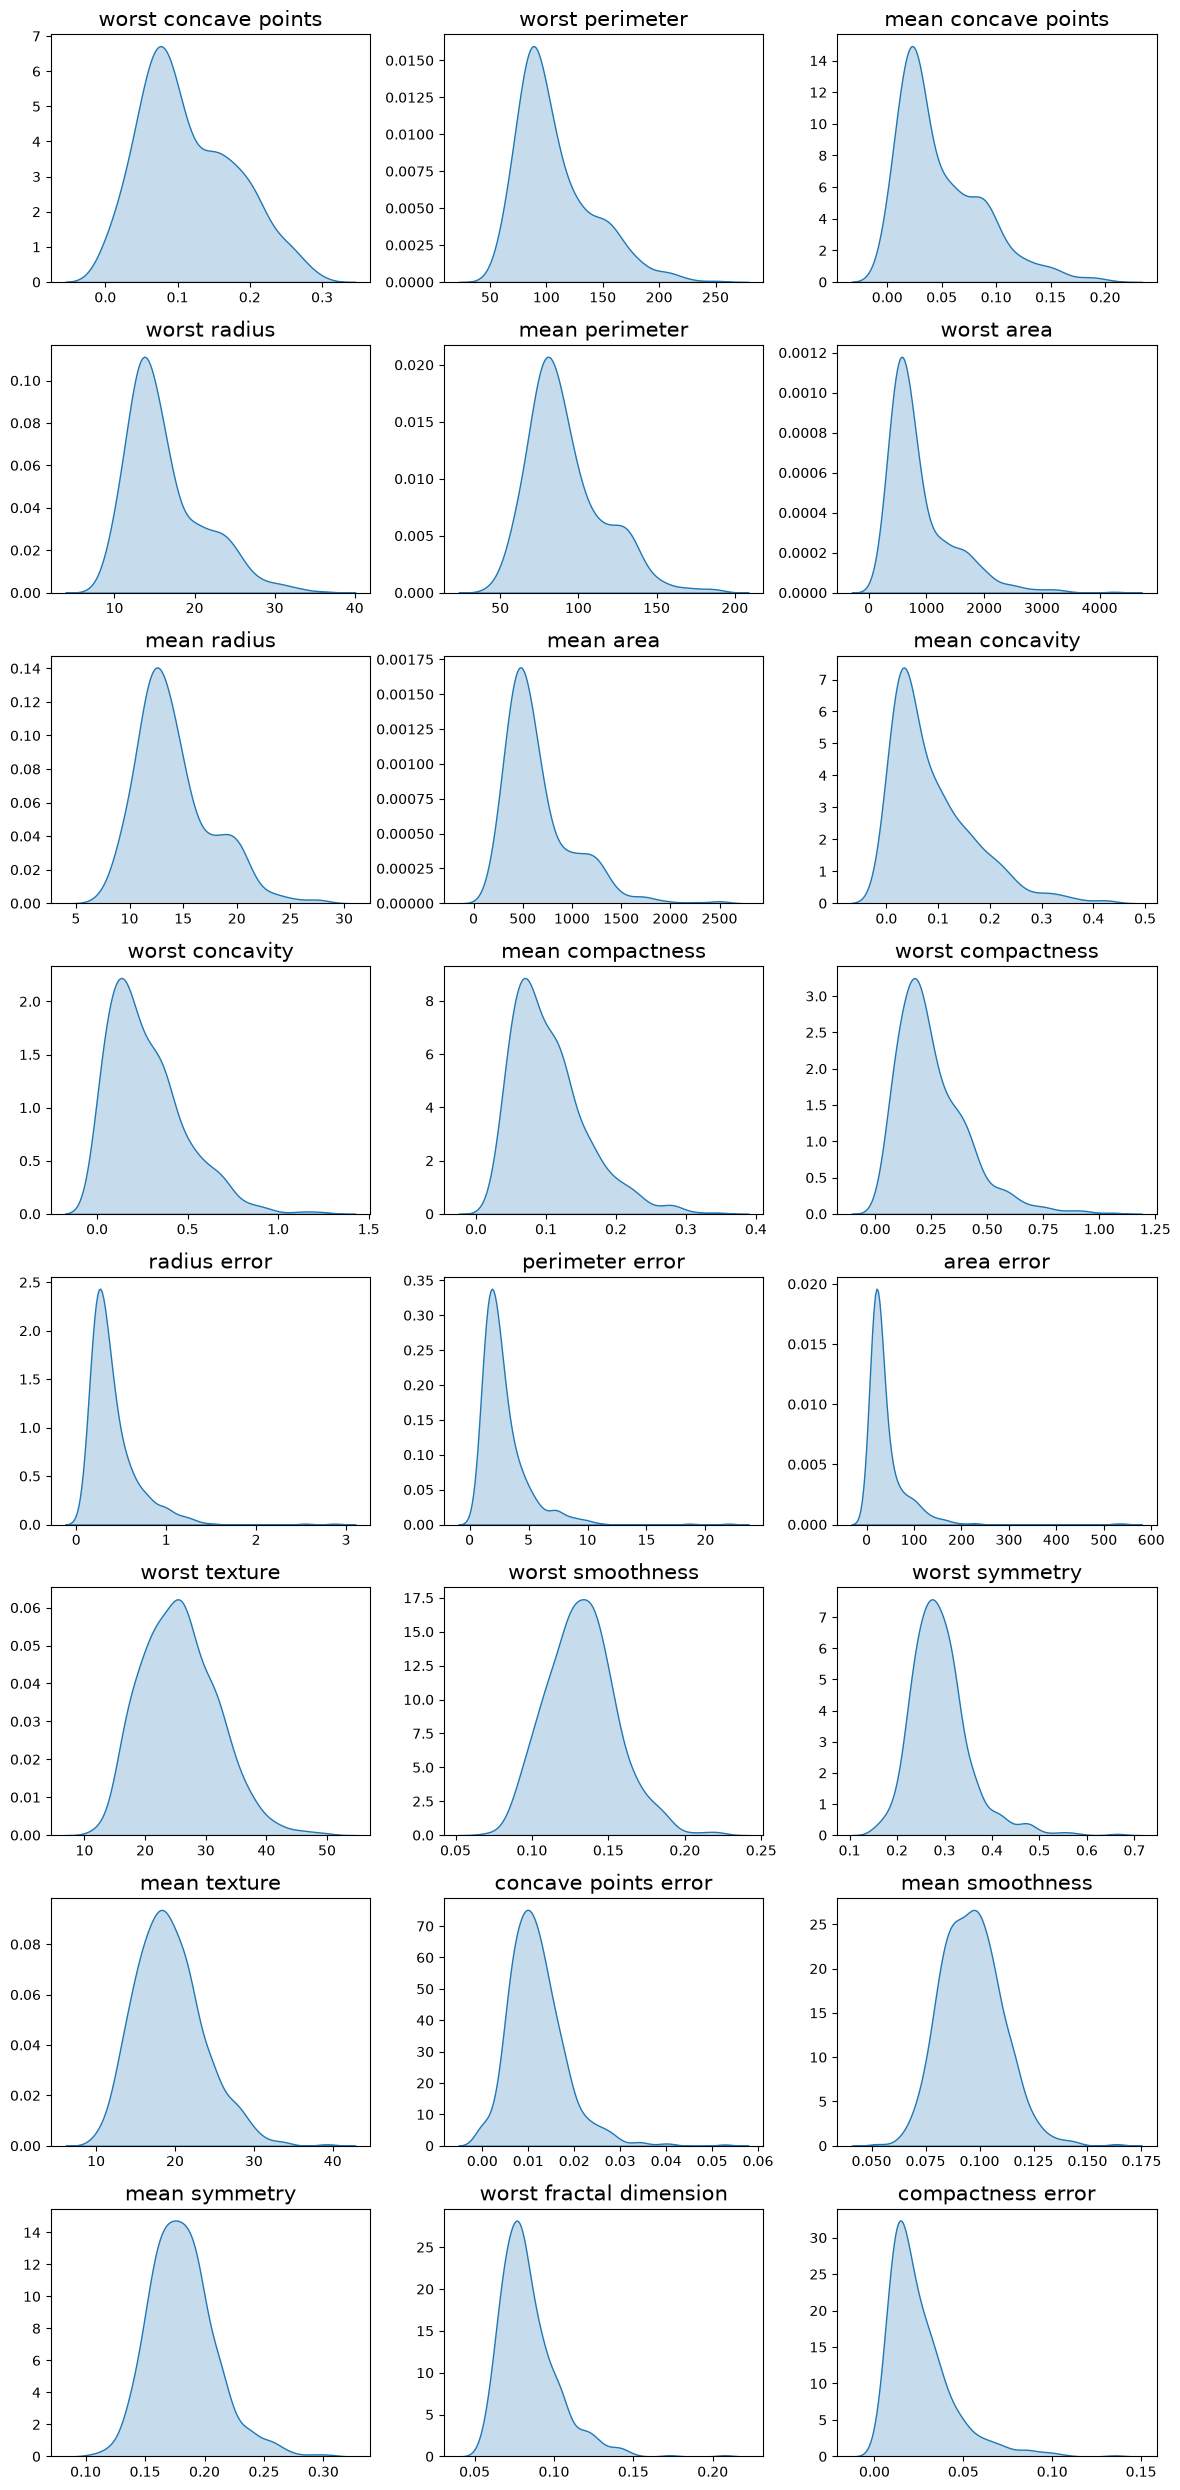

In [30]:
features = ['worst concave points' ,"worst perimeter", 
"mean concave points",     
"worst radius",             
"mean perimeter",            
"worst area",                
"mean radius",                
"mean area",                 
"mean concavity",            
"worst concavity",            
"mean compactness",      
"worst compactness",          
"radius error",               
"perimeter error",            
"area error",
 "worst texture",
"worst smoothness",
"worst symmetry", 
"mean texture",
"concave points error",
"mean smoothness",
"mean symmetry",
"worst fractal dimension",
"compactness error"]  
fig, axes = plt.subplots(8,3, figsize=(12, 25))

axes = axes.flatten()

for ax, col in zip(axes, features):
    sns.kdeplot(data=df, x=col, fill=True, ax=ax)
    ax.set_title(col, fontsize=15)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

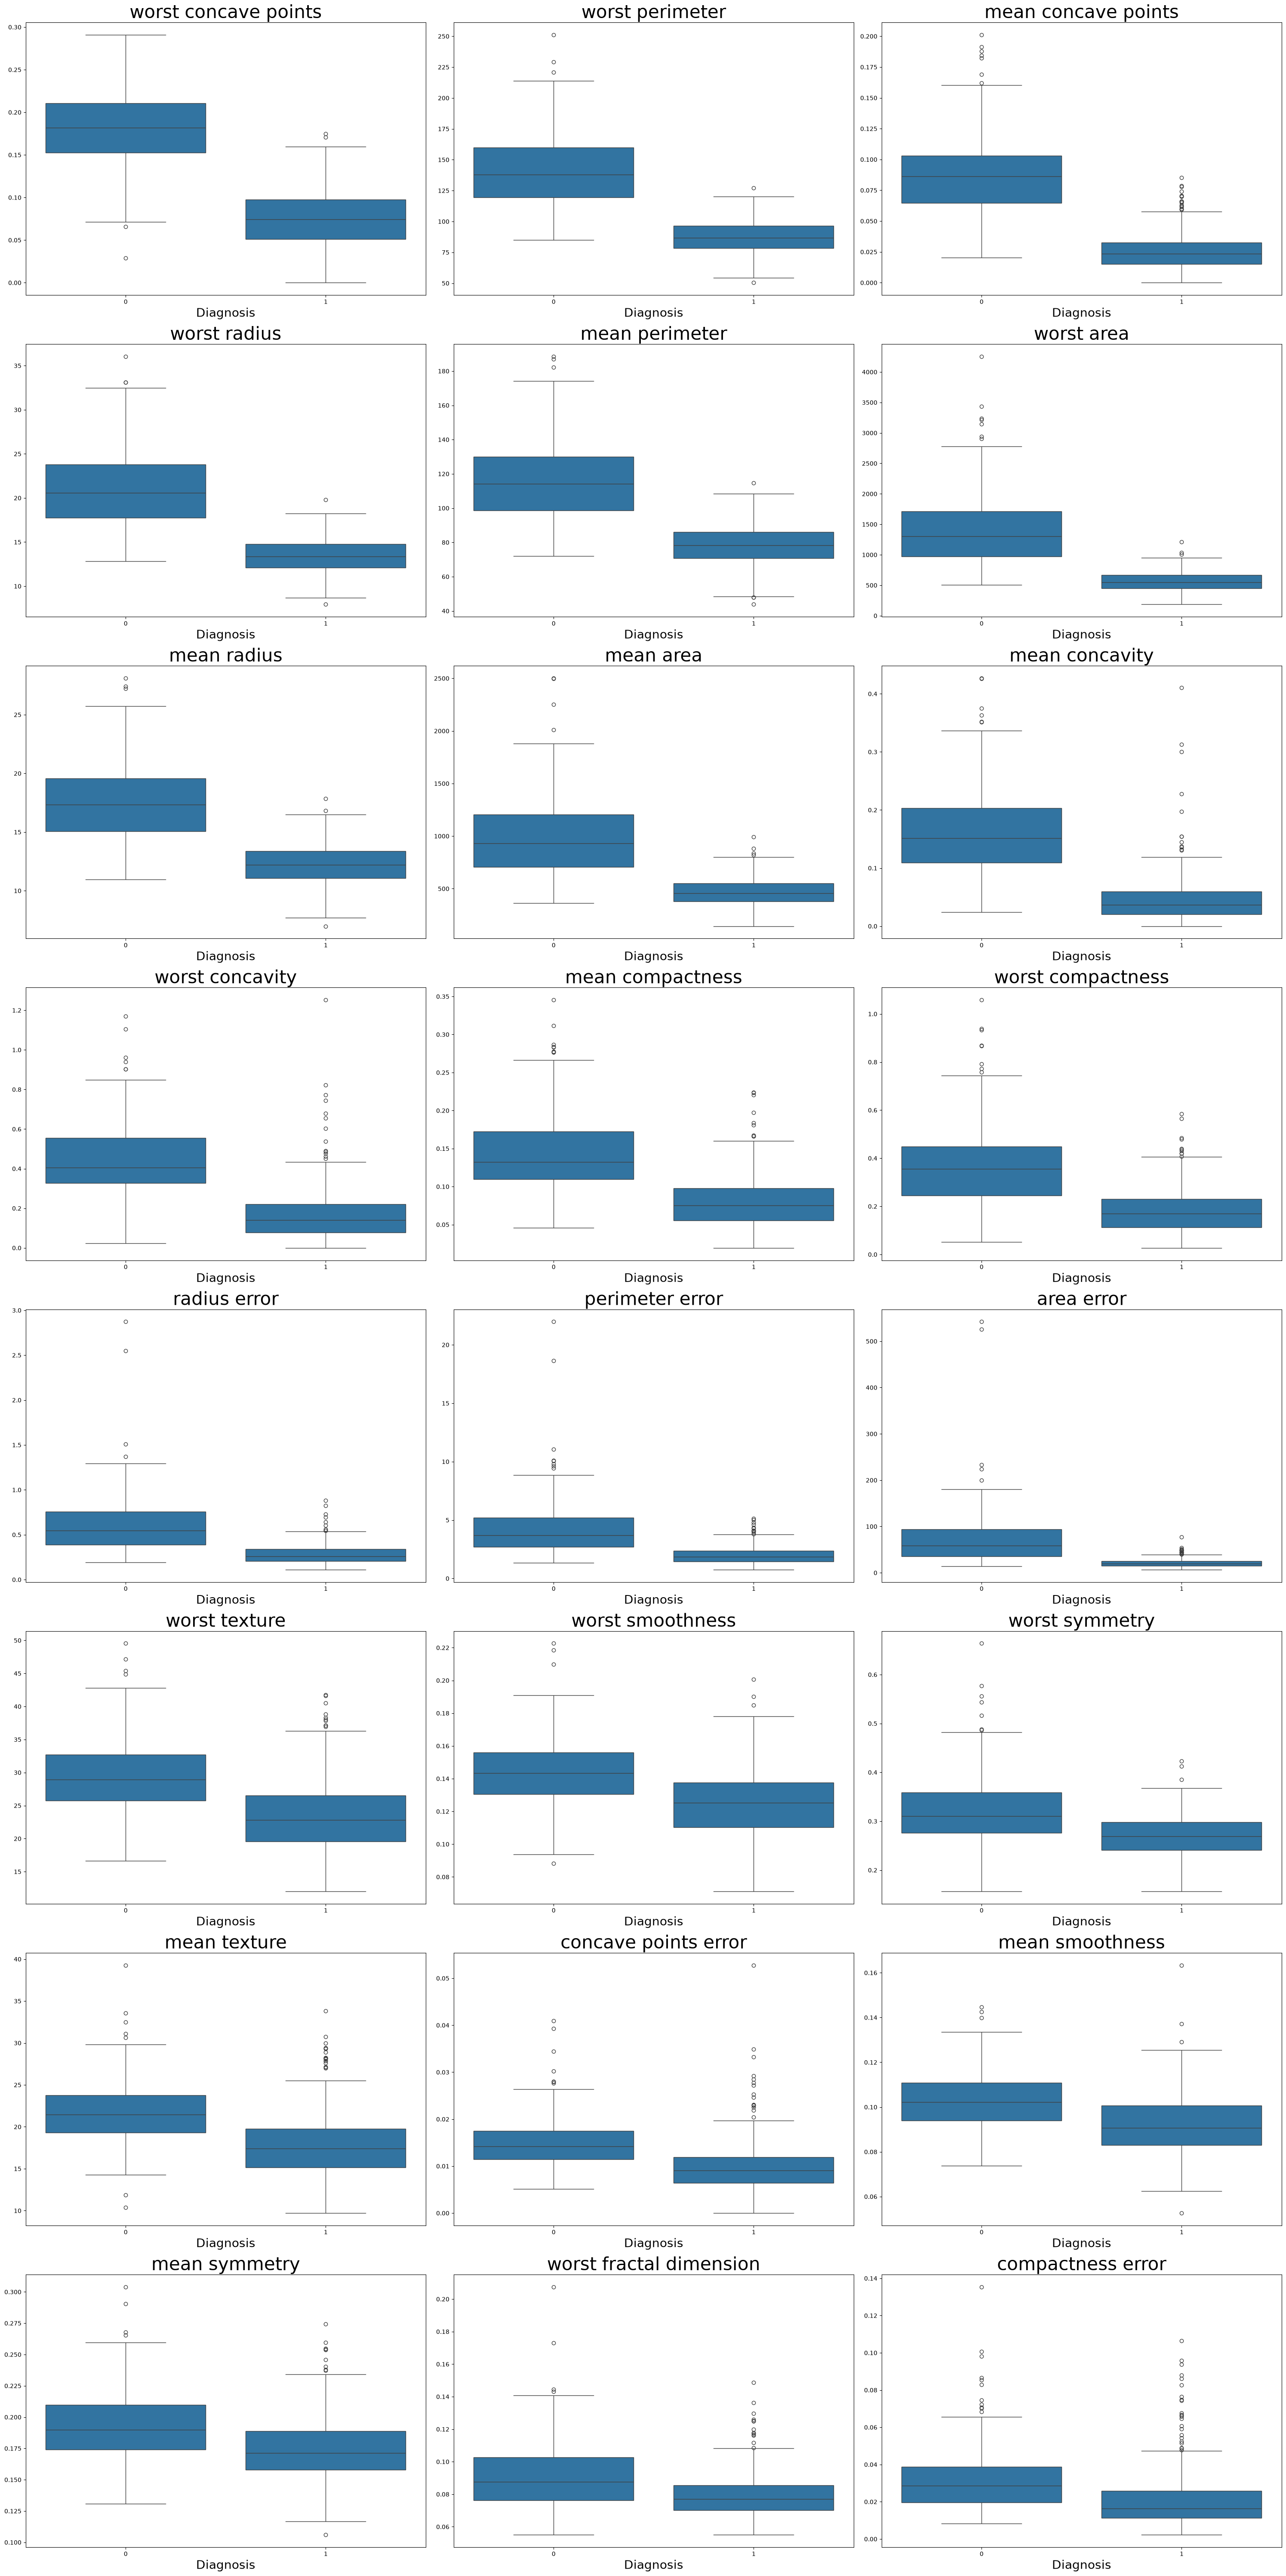

In [31]:
fig, axes = plt.subplots(8, 3, figsize=(30, 60))

axes = axes.flatten()

for ax, col in zip(axes, features):
    sns.boxplot(data=df, x='benign_0__mal_1', y=col, ax=ax)
    ax.set_title(col, fontsize=30)
    ax.set_xlabel("Diagnosis", fontsize=20)
    ax.set_ylabel("", fontsize=20)

plt.tight_layout()
plt.show()

* The boxplots show that many features have different values for the two diagnosis groups.
*  Features such as radius, perimeter, area, concavity, and compactness show clear differences between the groups. This means these features may be useful for predicting the diagnosis.
* Some features, such as smoothness, symmetry, fractal dimension, and several error features, show more overlap between the two diagnosis groups.

**FEATURE ENGINEERING**

In [32]:
df['radius_change'] = df['worst radius'] - df['mean radius']
df['area_change'] = df['worst area'] - df['mean area']
df['perimeter_change'] = df['worst perimeter'] - df['mean perimeter']


**SPLITTING THE DATA**

In [33]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(455, 30)
(114, 30)
(455,)
(114,)


**LOGISTIC REGRESSION**

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42))
])


**HYPERTUNING OF LOGISTIC REGRESSION**

In [35]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear']
}

grid_lr = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_lr.fit(x_train, y_train)

print("Best Parameters:", grid_lr.best_params_)
print("Best CV Accuracy:", grid_lr.best_score_)


Best Parameters: {'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best CV Accuracy: 0.9802197802197803


c:\Users\Dell\OneDrive\Desktop\cancer prediction project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


**TESTING THE TUNED LOGISTIC REGRESSION MODEL**

In [36]:
best_lr = grid_lr.best_estimator_

y_pred_lr = best_lr.predict(x_test)

**CLASSIFICATION REPORT AND CONFUSION MATRIX OF MODEL TRAINED BY LOGISTIC REGRESSION**


Classification Report:
                     precision    recall  f1-score   support

   Class 0 (Benign)   0.976190  0.976190  0.976190        42
Class 1 (Malignant)   0.986111  0.986111  0.986111        72

           accuracy                       0.982456       114
          macro avg   0.981151  0.981151  0.981151       114
       weighted avg   0.982456  0.982456  0.982456       114



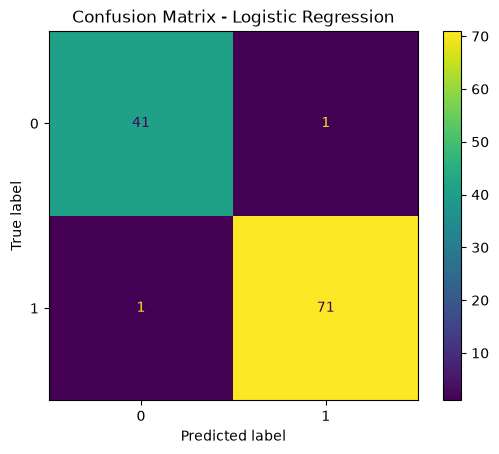

In [37]:
from sklearn.metrics import classification_report,confusion_matrix, ConfusionMatrixDisplay
print("\nClassification Report:")
print(classification_report(
    y_test, y_pred_lr,
    target_names=['Class 0 (Benign)', 'Class 1 (Malignant)'],
    digits=6
))
cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['0', '1']
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

**CONCLUSION**
* Precison of Benign is 97.6%
* Recall of Benign is 97.6%
* Total non-cancerous cell-42
* No. of correctly predicted non-cancercous cell(TN)-41

* No. of non-cancerous cell which are predicted as cancerous(FP)-1
* Precison of Malignant is 99%Recall of Malignant is 99%
* Total no. of cancercous cell-72
* No. of correctly predicted cancercous cell(TP)-71
* No. of cancerous cell which are predicted as non-cancerous(FN)-1


**RANDOM FOREST REGRESSION**

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42))
])


**HYPERTUNING OF RANDOM FOREST REGRESSION**

In [39]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(x_train, y_train)

print("Best Parameters:", grid_rf.best_params_)
print("Best Accuracy:", grid_rf.best_score_)

Best Parameters: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 100}
Best Accuracy: 0.9604395604395606


**TESTING THE TUNED RANDOM FOREST REGRESSION MODEL**

In [40]:
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(x_test)

**CLASSIFICATION REPORT AND CONFUSION MATRIX OF RANDOM FOREST REGRESSION**


Classification Report:
                     precision    recall  f1-score   support

   Class 0 (Benign)   0.951220  0.928571  0.939759        42
Class 1 (Malignant)   0.958904  0.972222  0.965517        72

           accuracy                       0.956140       114
          macro avg   0.955062  0.950397  0.952638       114
       weighted avg   0.956073  0.956140  0.956027       114



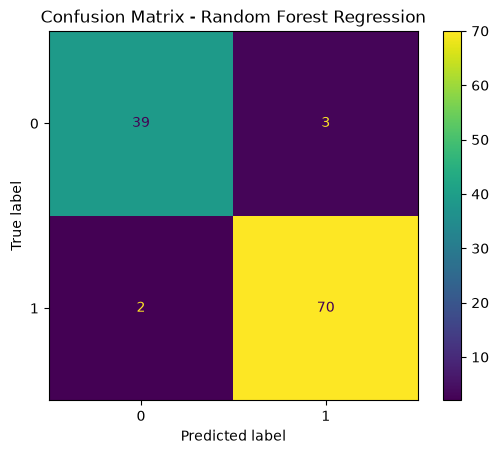

In [41]:
from sklearn.metrics import classification_report,confusion_matrix, ConfusionMatrixDisplay
print("\nClassification Report:")
print(classification_report(
    y_test, y_pred_rf,
    target_names=['Class 0 (Benign)', 'Class 1 (Malignant)'],
    digits=6
))
cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['0', '1']
)
disp.plot()
plt.title("Confusion Matrix - Random Forest Regression")
plt.show()

    


**CONCLUSION BY RANDOM FOREST REGRESSION**

* Precison of Benign is 95.2%
* Recall of Benign is 92.8%
* Total non-cancerous cell-42
* No. of correctly predicted non-cancercous cell(TN)-39
* No. of non-cancerous cell which are predicted as cancerous(FP)-3
* Precison of Malignant is 95.2%
* Recall of Malignant is 97.22%
* Total no. of cancercous cell-72
* No. of correctly predicted cancercous cell(TP)-70
* No. of cancerous cell which are predicted as non-cancerous(FN)-2

**XG BOOST REGRESSION**


In [42]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ))
])


In [43]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_xgb.fit(x_train, y_train)

print("Best Parameters:", grid_xgb.best_params_)
print("Best Accuracy:", grid_xgb.best_score_)

Best Parameters: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.2, 'model__max_depth': 5, 'model__n_estimators': 100, 'model__subsample': 0.8}
Best Accuracy: 0.9824175824175825


**TESTING THE TUNED XGBOOST REGRESSION**

In [44]:
best_xgb = grid_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(x_test)

**CLASSIFICATION REPORT AND CONFUSION MATRIX OF XG BOOST REGRESSION**


Classification Report:
                     precision    recall  f1-score   support

   Class 0 (Benign)   0.974359  0.904762  0.938272        42
Class 1 (Malignant)   0.946667  0.986111  0.965986        72

           accuracy                       0.956140       114
          macro avg   0.960513  0.945437  0.952129       114
       weighted avg   0.956869  0.956140  0.955776       114



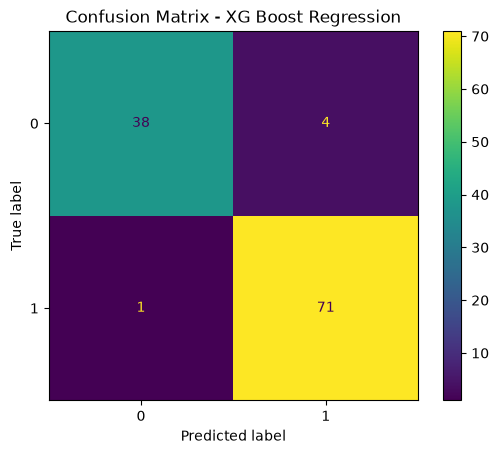

In [45]:
from sklearn.metrics import classification_report,confusion_matrix, ConfusionMatrixDisplay
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=['Class 0 (Benign)', 'Class 1 (Malignant)'],
    digits=6
    
))
cm = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['0', '1']
)

disp.plot()
plt.title("Confusion Matrix - XG Boost Regression")
plt.show()

**CONCLUSION BY XGBOOST REGRESSION**

* Precison of Benign is 92.68%
* Recall of Benign is 90%
* Total non-cancerous cell-42
* No. of correctly predicted non-cancercous cell(TN)-38
* No. of non-cancerous cell which are predicted as cancerous(FP)-4
* Precison of Malignant is 94.5%
* Recall of Malignant is 95.83%
* Total no. of cancercous cell-72
* No. of correctly predicted cancercous cell(TP)-69
* No. of cancerous cell which are predicted as non-cancerous(FN)-3


**COMPARISON TABLE**

In [46]:
from sklearn.metrics import accuracy_score, precision_score,recall_score
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],

    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],

    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],

    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ]
})

print(comparison)

                 Model  Accuracy  Precision    Recall
0  Logistic Regression  0.982456   0.986111  0.986111
1        Random Forest  0.956140   0.958904  0.972222
2              XGBoost  0.956140   0.946667  0.986111


**MODEL SELECTION**

* For the model selection, Recall plays a cruical role.
* Recall  in case1 determines how many cancerous cells have been correctly determined out of total no.cancerous cells are present by the prediction.
* 2nd important deciding factor is precision which states how many actually have cancer out of all what my model predicted as cancer.
* From the comparison table, recall for logistic regression is highest.
* Precision for logistic regression is highest. 
* Therefore logistic regression is considered asd the best model for deteriming the prediction of cancer. 

**FINAL MODEL INTERPRETATION**

In [47]:
lr_model = best_lr.named_steps['model']

feature_names = x_train.columns

coefficients = pd.Series(
    lr_model.coef_[0],
    index=feature_names
)
feature_importance = coefficients.abs().sort_values(ascending=False)

print(feature_importance)

worst texture              0.548639
worst radius               0.515598
worst concave points       0.496777
worst area                 0.495664
worst perimeter            0.472829
radius error               0.459034
mean texture               0.428021
mean concave points        0.413799
area error                 0.409919
worst symmetry             0.405547
mean area                  0.394817
worst smoothness           0.390018
mean radius                0.389868
mean perimeter             0.377688
worst concavity            0.351660
perimeter error            0.329511
mean concavity             0.309827
compactness error          0.234016
fractal dimension error    0.219744
mean fractal dimension     0.188464
mean smoothness            0.175088
mean symmetry              0.153083
worst compactness          0.146743
concave points error       0.138780
symmetry error             0.128409
worst fractal dimension    0.126729
concavity error            0.093035
smoothness error           0

**GRAPHICAL REPRESENTATION OF MODEL INTERPRETATION**

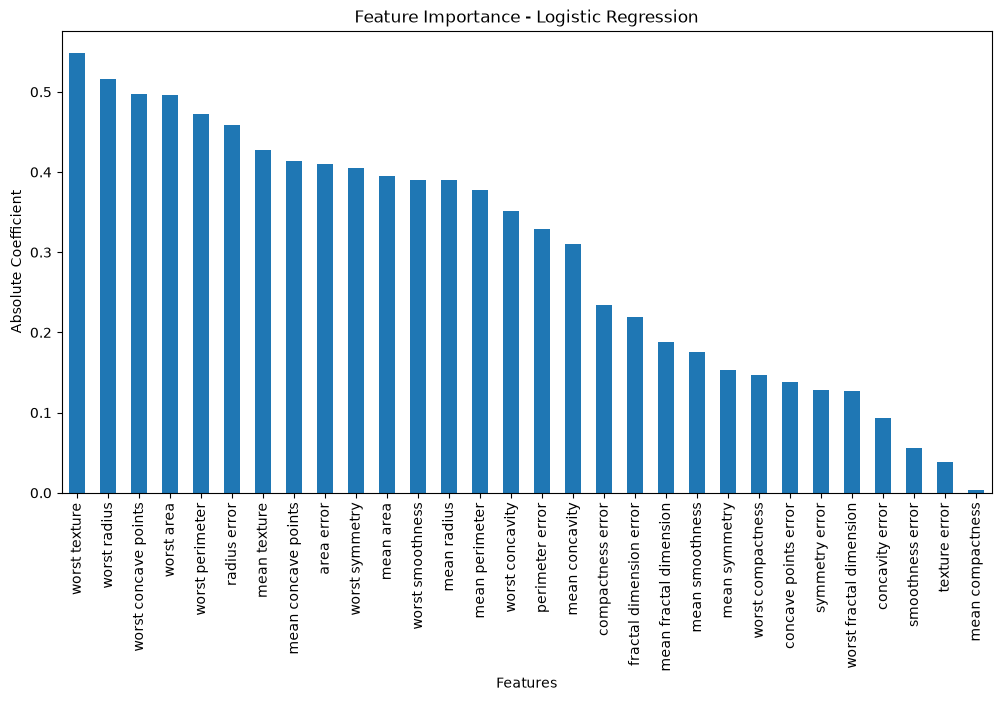

In [48]:
feature_importance.plot(kind='bar', figsize=(12, 6))

plt.title("Feature Importance - Logistic Regression")
plt.xlabel("Features")
plt.ylabel("Absolute Coefficient")
plt.xticks(rotation=90)
plt.show()

**INTERPRETATION**
* Important features from the grapgh are mentioned below:
  * worst texture
  * worst radius
  * worst concave points
  * worst area
  * worst perimeter
  * radius error
  * mean texture
  * mean concave points
  * area error
  * worst symmetry
  * mean area
  * worst smoothness
  * mean perimeter
     

In [49]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(best_lr, "models/final_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [50]:
import joblib

loaded_model = joblib.load("models/final_model.pkl")

print("Model loaded successfully!")
print(loaded_model)

Model loaded successfully!
Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(C=0.1, penalty='l2', random_state=42,
                                    solver='liblinear'))])


In [51]:
print("Number of features:", loaded_model.n_features_in_)
print("Feature names:")
print(x.columns.tolist())

Number of features: 30
Feature names:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']
